Estimating VLE Data for Ethanol-Water System using Non-Random Two Liquid (NRTL) Model

In [13]:
# Water-Ethanol System 
import numpy as np 
import pandas as pd

#a12 and a21 are interaction energy parameters in J/mol
#alpha is the non randomness parameter
#Source: Gmehling & Onken, DECHEMA VLE Data Collection

nrtl_params = {
    'a12' : 1804.9,
    'a21' : 902.0,
    'alpha' : 0.3
}

def NRTL(x1, T_K, nrtl_params):
    a12 = nrtl_params['a12']
    a21 = nrtl_params['a21']
    alpha = nrtl_params['alpha']
    #Gas constant
    R = 8.314
    #Temperature dependent factors
    tau_12 = a12/(R * T_K)
    tau_21 = a21/(R * T_K)
    #Boltzmann constants
    G12 = np.exp(-alpha*tau_12)
    G21 = np.exp(-alpha*tau_21)

    x2 = 1 - x1 #Binary mixture
    
    #Activity coefficients 
    gamma1 = np.exp((x2**2)*(((tau_21)*(G21/(x1 + x2*G21))**2) + (tau_12*G12)/(x2 + x1*G12)**2))
    gamma2 = np.exp((x1**2)*(((tau_12)*(G12/(x2 + x1*G12))**2) + (tau_21*G21)/(x1 + x2*G21)**2))
    return gamma1, gamma2
    

In [14]:
# Antoine Equation 
def Antoine(params, T_C):
    A = params['A']
    B = params['B']
    C = params['C']
    
    #Psat in mmHg
    Psat_mmHg = 10**(A - B/(T_C + C)) 
    return Psat_mmHg

In [15]:
#To solve for bubble point temperature by iterating - NEWTON RAPHSON Method
#To solve for bubble point temperature by iterating - NEWTON RAPHSON Method
def bubble_point(x1, T_guess=90, P=760):
    x2 = 1 - x1
    param1 = {'A': 8.11220, 'B': 1592.864, 'C': 226.184}  # ethanol
    param2 = {'A': 8.07131, 'B': 1730.63, 'C': 233.426}   # water

    T_C = T_guess

    for i in range(200):
        T_K = T_C + 273.15

        gamma1, gamma2 = NRTL(x1, T_K, nrtl_params)
        P1_sat = Antoine(param1, T_C)
        P2_sat = Antoine(param2, T_C)

        P_guess = x1*gamma1*P1_sat + x2*gamma2*P2_sat
        abs_e = abs(P - P_guess)
        if abs_e < 0.001:
            break
        # Newton Raphson Method: T(i + 1) = T(i) - f(T)/f'(T)
        dT = 0.01
        gamma1_b, gamma2_b = NRTL(x1, T_K + dT, nrtl_params)
        P1_sat_b = Antoine(param1, T_C + dT)
        P2_sat_b = Antoine(param2, T_C + dT)
        P_guess_b = x1*gamma1_b*P1_sat_b + x2*gamma2_b*P2_sat_b

        dPdT = (P_guess_b - P_guess)/dT
        T_C = T_C - (P_guess - P)/dPdT

    gamma1_final, gamma2_final = NRTL(x1, T_C + 273.15, nrtl_params)
    P1_sat_final = Antoine(param1, T_C)
    y1 = x1*gamma1_final*P1_sat_final/P
    return y1, T_C
    
        

In [16]:
def TxyCurve(P):
    x_vals = np.linspace(0, 1, 100)
    y_vals = []
    T_vals = []
    #Calculate the value of T for each x using the bubble point function, which returns y1 and T. 
    for x in x_vals:
        T_C = 100 - x*(100 - 78.5)
        y,T = bubble_point(x, T_C, P)
        y_vals.append(y)
        T_vals.append(T)
    return x_vals, y_vals, T_vals


(2.1099210059057505, 1.0019236780108418)


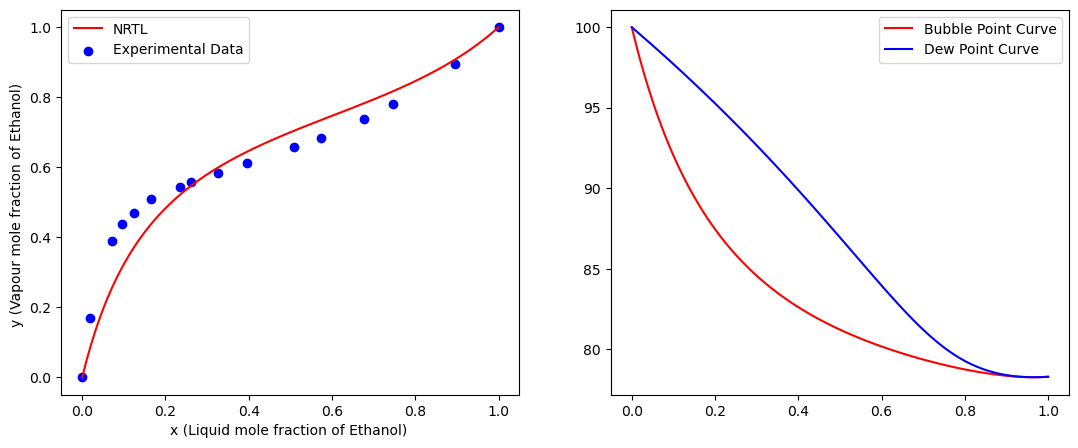

In [17]:
import matplotlib.pyplot as plt
x_nrtl, y_nrtl, T_nrtl = TxyCurve(760)
#Experimental Values
x_exp = [0.0, 0.019, 0.0721, 0.0966, 0.1238, 0.1661,
             0.2337, 0.2608, 0.3273, 0.3965, 0.5079,
             0.5732, 0.6763, 0.7472, 0.8943, 1.0]
y_exp = [0.0, 0.170, 0.3891, 0.4375, 0.4704, 0.5089,
             0.5445, 0.5580, 0.5830, 0.6122, 0.6564,
             0.6841, 0.7385, 0.7815, 0.8943, 1.0]
figs, axes = plt.subplots(1, 2, figsize = (13, 5))
axes[0].plot(x_nrtl, y_nrtl, 'r-', label = 'NRTL')
axes[0].scatter(x_exp, y_exp, color = 'blue', label = 'Experimental Data')
axes[0].set_xlabel('x (Liquid mole fraction of Ethanol) ')
axes[0].set_ylabel('y (Vapour mole fraction of Ethanol) ')
axes[0].legend()
axes[1].plot(x_nrtl, T_nrtl, 'r-', label = 'Bubble Point Curve')
axes[1].plot(y_nrtl, T_nrtl, 'b-', label = 'Dew Point Curve')
axes[1].legend()
print(NRTL(0.05, 78.5 + 273.15, nrtl_params))